In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import random

# ══════════════════════════════════════════════════════════════════════════════
# HybridQNN — QNI-CCP FROM EPOCH 1 (Virus-MNIST)
#
# PURPOSE:
#   Mirrors the Malimg QNI-CCP pipeline exactly for fair comparison:
#     1. Load pretrained clean checkpoint
#     2. Apply QNI-CCP from epoch 1 — no staging, no warm-up
#     3. Same loss formula & weights as Malimg (0.625 / 0.250 / 0.125)
#     4. Fixed FocalLoss gamma=2.0 (no scheduling)
#     5. Centroids recomputed every 5 epochs
#
# KEY DIFFERENCES FROM MALEVIS VERSION:
#   - num_classes  : 10  (not 26)
#   - image size   : 32x32  (not 224x224)
#   - dataset paths: Virus-MNIST paths
#   - n_qubits     : 8  (matches your Virus-MNIST clean model)
#   - Architecture : HybridResNet (ResNet backbone) not HybridQNN (FeatureReduce)
#
# QNI-CCP LATENT SPACE:
#   tanh(feature_extractor(x)) — n_qubits-dim vector before quantum layer
#   Equivalent to the 64-dim GAP output in the Malimg version.
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# CONFIG  — Virus-MNIST specific
# ─────────────────────────────────────────────
n_qubits     = 8         # matches your Virus-MNIST clean model
q_depth      = 6
batch_size   = 32        # 32x32 images — can afford larger batch than MaleVis
num_classes  = 10        # Virus-MNIST has 10 classes
num_epochs   = 40        # fine-tuning on top of clean checkpoint
lr           = 0.0002    # lower than clean training to preserve learned weights
weight_decay = 0.005

CIRCUIT_DEPTH = q_depth
N_CNOTS       = CIRCUIT_DEPTH * (n_qubits - 1)   # 42

# QNI-CCP epsilon from circuit complexity
EPSILON_ALPHA = 1.0
EPSILON_BETA  = 1.0
EPSILON_Q     = 1.0 / (1 + EPSILON_ALPHA * N_CNOTS + EPSILON_BETA * CIRCUIT_DEPTH)
print(f"Quantum epsilon (ε_q): {EPSILON_Q:.6f}")

# Loss weights — identical to Malimg, sum to 1.00
W_CLEAN    = 0.625
W_QNI      = 0.250
W_CENTROID = 0.125

# Paths
TRAIN_PATH       = 'virus_MNIST dataset/train'
VAL_PATH         = 'virus_MNIST dataset/val'
TEST_PATH        = 'virus_MNIST dataset/test'
CLEAN_CHECKPOINT = 'hybrid_resnet_NOGAN.pth'   # your pretrained Virus-MNIST clean model
SAVE_PATH        = 'QNI1.pth'


# ─────────────────────────────────────────────
# TRANSFORMS  — 32x32 grayscale (Virus-MNIST)
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# ─────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────
try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Datasets loaded: {len(train_dataset)} train | "
          f"{len(val_dataset)} val | {len(test_dataset)} test")
except Exception as e:
    print(f"Error loading datasets: {e}")
    raise

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", np.round(class_weights, 3))
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ─────────────────────────────────────────────
# QUANTUM CIRCUIT
# ─────────────────────────────────────────────
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: RY + RZ per qubit (2 * n_qubits inputs from bridge)
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)
        qml.RZ(inputs[..., i + n_qubits], wires=i)

    # Variational layers with brick CRZ entanglement + data re-uploading
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])

        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)

    # 3-axis Pauli measurement → 3 * n_qubits = 24 expectation values
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}
q_out_dim     = 3 * n_qubits   # 24


# ─────────────────────────────────────────────
# BUILDING BLOCKS
# ─────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """
    Compresses 64-dim backbone GAP features → 2*n_qubits=16 quantum angles.
    This is the latent space QNI-CCP operates on.
    """
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias


# ─────────────────────────────────────────────
# MAIN MODEL  — HybridResNet (Virus-MNIST architecture)
# ─────────────────────────────────────────────
class HybridResNet(nn.Module):
    """
    Data flow:
      (B,1,32,32)
      → stem    (1→16)                         → (B,16,32,32)
      → stage1  (16→16 ×2)                     → (B,16,32,32)
      → stage2  (16→32, stride=2 ×2)           → (B,32,16,16)
      → stage3  (32→64, stride=2 ×2)           → (B,64, 8, 8)
      → GAP → flatten                          → (B,64)
      → bridge  (64 → 2*n_qubits=16)           → (B,16)   ← QNI-CCP latent space
      → q_layer (16 → 3*n_qubits=24)           → (B,24)
      → classifier (24 → num_classes=10)       → (B,10)
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),
            ResBlock(16, 16, drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32,           drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64,           drop_path=0.20)
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.bridge     = QuantumBridge(in_features=64, n_qubits=n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # (B, 64)
        x = self.bridge(x)           # (B, 16) ← QNI-CCP targets this
        x = self.q_layer(x)          # (B, 24)
        return self.classifier(x)    # (B, 10)


# ─────────────────────────────────────────────
# FOCAL LOSS  (fixed gamma=2.0 — no scheduling)
# ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(
            inputs, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# ══════════════════════════════════════════════════════════════════════════════
# QNI-CCP COMPONENTS
# ══════════════════════════════════════════════════════════════════════════════

def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean bridge output per class — the 2*n_qubits=16 dim vector
    fed into the quantum layer. This is the QNI-CCP latent space.
    Equivalent to the 64-dim GAP centroids in the Malimg version.

    Returns: (num_classes, 2*n_qubits) tensor
    """
    latent_dim   = n_qubits * 2   # 16
    model.eval()
    sum_features = torch.zeros(num_classes, latent_dim, device=device)
    count        = torch.zeros(num_classes,              device=device)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y = x.to(device), y.to(device)

            # Extract latent vector: GAP → flatten → bridge output
            feat = model.stem(x)
            feat = model.stage1(feat)
            feat = model.stage2(feat)
            feat = model.stage3(feat)
            feat = model.gap(feat)
            feat = feat.view(feat.size(0), -1)   # (B, 64)
            feat = model.bridge(feat)             # (B, 16) ← centroid space

            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_features[c] += feat[mask].sum(dim=0)
                    count[c]        += mask.sum()

    count     = count.clamp(min=1.0)
    centroids = sum_features / count.unsqueeze(1)
    return centroids   # (num_classes, 16)


def qni_ccp_loss(model, x, y, centroids, epsilon_q):
    """
    QNI-CCP adversarial loss in bridge output space (16-dim).
    Exact same logic as Malimg version — only the latent space dim differs.

    Steps:
      1. Extract bridge output z (B,16) with grad tracking
      2. z → q_layer → classifier → logits
      3. CE → backward → z.grad = sensitivity S
      4. ℓ2 normalise S per sample
      5. Random wrong class c' → centroid μ_{c'}
      6. z' = z + ε_q * (S_norm ⊙ (μ_{c'} - z))
      7. z' → q_layer → classifier → CE loss

    Returns: scalar CE loss on perturbed features
    """
    model.eval()

    # Step 1: extract bridge output, re-attach grad
    with torch.no_grad():
        feat = model.stem(x)
        feat = model.stage1(feat)
        feat = model.stage2(feat)
        feat = model.stage3(feat)
        feat = model.gap(feat)
        feat = feat.view(feat.size(0), -1)   # (B, 64)
        z_raw = model.bridge(feat)           # (B, 16)

    z = z_raw.detach().requires_grad_(True)

    # Step 2: post-bridge forward
    q_out  = model.q_layer(z)
    logits = model.classifier(q_out)

    # Step 3: sensitivity
    F.cross_entropy(logits, y).backward()
    S      = z.grad.detach()
    S_norm = S / (S.norm(dim=1, keepdim=True) + 1e-8)

    # Step 4: wrong class centroid
    z_det = z.detach()
    wrong_classes = []
    for i in range(y.size(0)):
        candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
        wrong_classes.append(candidates[torch.randint(0, len(candidates), (1,)).item()])
    wrong_idx  = torch.tensor(wrong_classes, device=device)
    mu_c_prime = centroids[wrong_idx]   # (B, 16)

    # Step 5: perturb
    delta       = mu_c_prime - z_det
    z_perturbed = z_det + epsilon_q * (S_norm * delta)

    # Step 6: forward perturbed features
    model.train()
    q_out_p  = model.q_layer(z_perturbed)
    logits_p = model.classifier(q_out_p)
    return F.cross_entropy(logits_p, y)


# ─────────────────────────────────────────────
# TRAINING & EVALUATION
# ─────────────────────────────────────────────
def train_qni_epoch(model, dataloader, optimizer, loss_fn, centroids, device):
    """
    One epoch — QNI-CCP active from the very first batch.
    loss = 0.625*clean + 0.250*qni + 0.125*centroid_reg
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(dataloader, desc="QNI-CCP Training", leave=False):
        x, y = x.to(device), y.to(device)

        # ── Loss 1: Clean ─────────────────────────────────────────
        model.train()
        logits_clean = model(x)
        loss_clean   = loss_fn(logits_clean, y)

        # ── Loss 2: QNI-CCP ──────────────────────────────────────
        loss_qni = qni_ccp_loss(model, x, y, centroids, EPSILON_Q)

        # ── Loss 3: Centroid regularisation ───────────────────────
        model.train()
        feat = model.stem(x)
        feat = model.stage1(feat)
        feat = model.stage2(feat)
        feat = model.stage3(feat)
        feat = model.gap(feat)
        feat = feat.view(feat.size(0), -1)
        z_clean      = model.bridge(feat)           # (B, 16) graph-connected
        centroid_reg = ((z_clean - centroids[y]) ** 2).mean()

        # ── Combined ──────────────────────────────────────────────
        loss = (W_CLEAN    * loss_clean   +
                W_QNI      * loss_qni     +
                W_CENTROID * centroid_reg)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits_clean.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(dataloader), correct / total


def evaluate_clean(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y       = x.to(device), y.to(device)
            logits     = model(x)
            total_loss += loss_fn(logits, y).item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(dataloader), correct / total


def evaluate_qni_robustness(model, dataloader, device, centroids):
    """Accuracy under QNI-CCP perturbation at test time."""
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            feat = model.stem(x)
            feat = model.stage1(feat)
            feat = model.stage2(feat)
            feat = model.stage3(feat)
            feat = model.gap(feat)
            feat = feat.view(feat.size(0), -1)
            z_raw = model.bridge(feat)

        z = z_raw.detach().requires_grad_(True)
        q_out  = model.q_layer(z)
        logits = model.classifier(q_out)
        F.cross_entropy(logits, y).backward()

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)

        z_det = z.detach()
        wrong_classes = []
        for i in range(y.size(0)):
            candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
            wrong_classes.append(candidates[torch.randint(0, len(candidates), (1,)).item()])
        wrong_idx  = torch.tensor(wrong_classes, device=device)
        mu_c_prime = centroids[wrong_idx]

        z_perturbed = z_det + EPSILON_Q * (S_norm * (mu_c_prime - z_det))

        with torch.no_grad():
            q_out_p  = model.q_layer(z_perturbed)
            logits_p = model.classifier(q_out_p)
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

# ── Load pretrained clean checkpoint ─────────────────────────────────────────
try:
    ckpt = torch.load(CLEAN_CHECKPOINT, map_location=device)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"Loaded checkpoint : {CLEAN_CHECKPOINT}")
        print(f"Previous Val Acc  : {ckpt.get('val_acc', '?')}")
    else:
        model.load_state_dict(ckpt)
        print(f"Loaded bare state_dict from: {CLEAN_CHECKPOINT}")
except FileNotFoundError:
    print(f"⚠️  '{CLEAN_CHECKPOINT}' not found — starting from scratch.")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# ── Optimizer, scheduler, loss ────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)
loss_fn = FocalLoss(weight=class_weight_tensor, gamma=2.0, label_smoothing=0.1)

# ── Initial centroids ─────────────────────────────────────────────────────────
print("\nComputing initial class centroids...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
print(f"Centroids shape: {centroids.shape}")   # (10, 16)

# ── Training loop ─────────────────────────────────────────────────────────────
best_val_acc               = 0.0
early_stopping_patience    = 12
epochs_without_improvement = 0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

print(f"\nStarting QNI-CCP Training for {num_epochs} epochs (from epoch 1)")
print(f"Loss weights : clean={W_CLEAN} | QNI={W_QNI} | centroid={W_CENTROID}")
print(f"ε_q          : {EPSILON_Q:.6f}  |  Focal gamma: 2.0 (fixed)")
print("=" * 70)

for epoch in range(1, num_epochs + 1):

    if epoch % 5 == 0:
        print(f"  🔄 Recomputing centroids at epoch {epoch}...")
        centroids = compute_class_centroids(model, train_loader, device, num_classes)

    train_loss, train_acc = train_qni_epoch(
        model, train_loader, optimizer, loss_fn, centroids, device
    )
    val_loss, val_acc = evaluate_clean(model, val_loader, loss_fn, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch:02d}/{num_epochs}] | LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc':              val_acc,
            'val_loss':             val_loss,
            'config': {
                'n_qubits':    n_qubits,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'training':    'QNI-CCP_only',
                'epsilon_q':   EPSILON_Q,
                'w_clean':     W_CLEAN,
                'w_qni':       W_QNI,
                'w_centroid':  W_CENTROID,
            }
        }, SAVE_PATH)
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}.")
        break

    print("-" * 70)

print(f"\n✅ QNI-CCP training complete. Best Val Acc: {best_val_acc:.4f}")

# ── Final evaluation ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL EVALUATION — Virus-MNIST QNI-CCP MODEL")
print("=" * 70)

ckpt = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
centroids_final = compute_class_centroids(model, train_loader, device, num_classes)

_, clean_acc = evaluate_clean(model, test_loader, loss_fn, device)
qni_acc      = evaluate_qni_robustness(model, test_loader, device, centroids_final)

print(f"\n  Clean Test Accuracy        : {clean_acc:.4f}  ({clean_acc*100:.1f}%)")
print(f"  Under QNI-CCP Perturbation : {qni_acc:.4f}  ({qni_acc*100:.1f}%)")
print(f"  Robustness drop            : {(clean_acc - qni_acc)*100:.1f}%")
print(f"""
COMPARISON TABLE:
  Stage 1 — Clean baseline  ({CLEAN_CHECKPOINT})
  Stage 2 — QNI-CCP only   ({SAVE_PATH})

  Expected: QNI-CCP trained model shows much smaller robustness drop
  than clean baseline when attacked at test time.
""")

Using device: cuda
Quantum epsilon (ε_q): 0.020408
Datasets loaded: 43585 train | 4837 val | 3458 test
Class weights computed: [2.069 0.674 1.71  2.173 6.554 0.78  0.337 0.691 2.019 1.555]
Loaded checkpoint : hybrid_resnet_NOGAN.pth
Previous Val Acc  : 0.9177175935497209
Trainable parameters: 184,234

Computing initial class centroids...


Centroids shape: torch.Size([10, 16])

Starting QNI-CCP Training for 40 epochs (from epoch 1)
Loss weights : clean=0.625 | QNI=0.25 | centroid=0.125
ε_q          : 0.020408  |  Focal gamma: 2.0 (fixed)


Epoch [01/40] | LR: 0.000200
  Train Loss: 0.4118 | Train Acc: 0.9046
  Val   Loss: 0.4889  | Val   Acc: 0.9202
  💾 Best model saved (Val Acc: 0.9202)
----------------------------------------------------------------------


Epoch [02/40] | LR: 0.000200
  Train Loss: 0.4085 | Train Acc: 0.9015
  Val   Loss: 0.4948  | Val   Acc: 0.9076
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [03/40] | LR: 0.000200
  Train Loss: 0.4183 | Train Acc: 0.8951
  Val   Loss: 0.4878  | Val   Acc: 0.9061
  🕒 No improvement for 2 epoch(s).
----------------------------------------------------------------------


...

Epoch [22/40] | LR: 0.000025
  Train Loss: 0.3950 | Train Acc: 0.9059
  Val   Loss: 0.5059  | Val   Acc: 0.9208
  🕒 No improvement for 7 epoch(s).
----------------------------------------------------------------------


Epoch [23/40] | LR: 0.000025
  Train Loss: 0.3941 | Train Acc: 0.9079
  Val   Loss: 0.5122  | Val   Acc: 0.9183
  🕒 No improvement for 8 epoch(s).
----------------------------------------------------------------------


Epoch [24/40] | LR: 0.000025
  Train Loss: 0.3902 | Train Acc: 0.9109
  Val   Loss: 0.5185  | Val   Acc: 0.9132
  🕒 No improvement for 9 epoch(s).
----------------------------------------------------------------------
  🔄 Recomputing centroids at epoch 25...


Epoch [25/40] | LR: 0.000025
  Train Loss: 0.3964 | Train Acc: 0.9052
  Val   Loss: 0.5097  | Val   Acc: 0.9223
  🕒 No improvement for 10 epoch(s).
----------------------------------------------------------------------


QNI-CCP Training:  15%|█▍        | 204/1362 [01:36<10:09,  1.90it/s]

Using device: cuda
Test samples : 3458
Train samples: 48498 (used only for centroid computation)
Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Loading checkpoint: QNI1.pth
  Checkpoint from epoch : 15
  Saved val accuracy    : 0.9241
  Training type         : QNI-CCP_only
  Total parameters      : 184,234

STEP 1/4 — FEATURE EXTRACTION



  Samples extracted : 3458
  Feature dimension : 64  (GAP output before bridge)

STEP 2/4 — CLASSIFICATION REPORT

  Clean Test Accuracy : 0.9164  (91.64%)

              precision    recall  f1-score   support

           0     0.5079    0.3657    0.4252       175
           1     1.0000    0.9940    0.9970       496
           2     0.9018    0.9854    0.9417       205
           3     0.9659    0.9659    0.9659       176
           4     0.9831    1.0000    0.9915        58
           5     0.9587    0.9167    0.9372       456
           6     0.9552    0.9352    0.9451      1003
           7     0.8878    0.9185    0.9029       491
           8     0.8256    0.9306    0.8750       173
           9     0.8263    0.9511    0.8843       225

    accuracy                         0.9164      3458
   macro avg     0.8812    0.8963    0.8866      3458
weighted avg     0.9129    0.9164    0.9134      3458


STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION

Computing training-set centroids for QNI


Applying QNI-CCP attack on test set...



  Clean Test Accuracy         : 0.9164  (91.64%)
  Under QNI-CCP Perturbation  : 0.8988  (89.88%)
  Robustness drop             : 1.76 pp

STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)

  Metric                                   Value
  ---------------------------------------------
  Entropy (avg prediction entropy)        0.6420
  Feature Variance (avg across dims)      0.0870
  Unique Patterns                           2581
  High-confidence patterns (≥90%)          46.4%
  Average confidence                      0.8440
  Confidence std dev                      0.1345

GENERATING PLOTS

Running t-SNE dimensionality reduction...
  Input shape  : (3458, 64)  (N samples × 64 features)
  Output shape : (3458, 2)  (N samples × 2 t-SNE dimensions)


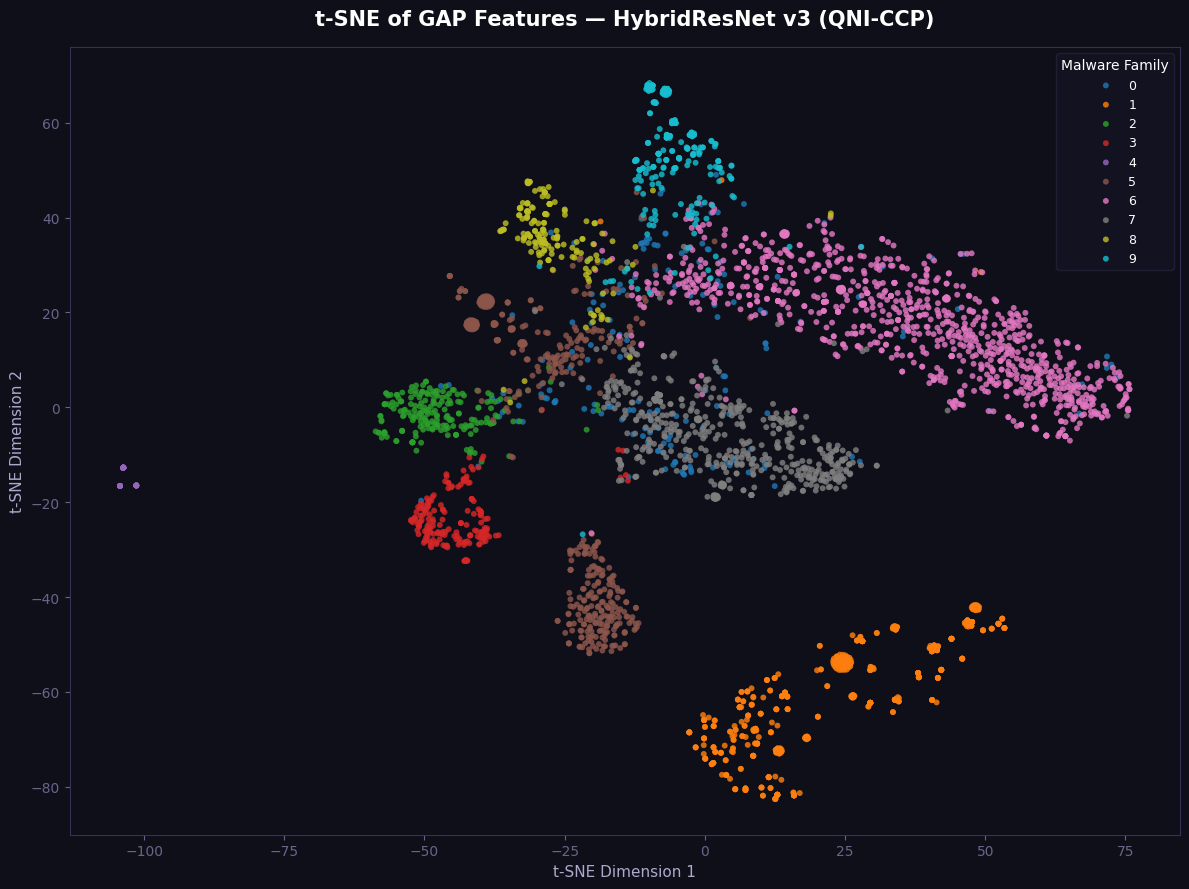

  t-SNE plot saved → tsne_qni_model.png


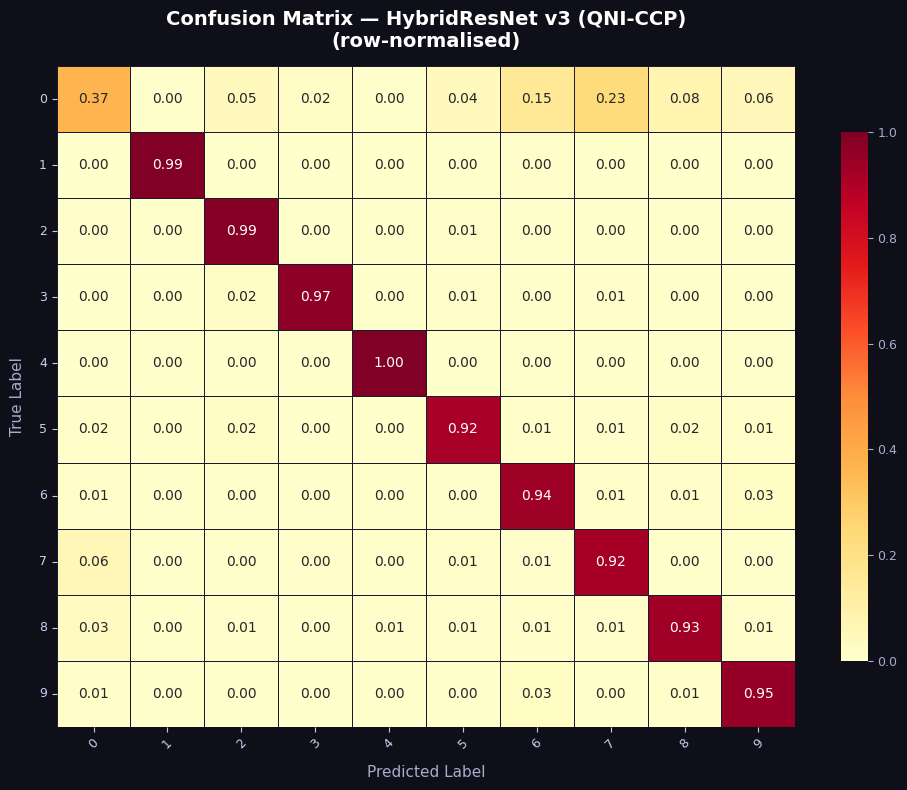

  Confusion matrix saved → confusion_matrix_qni_model.png


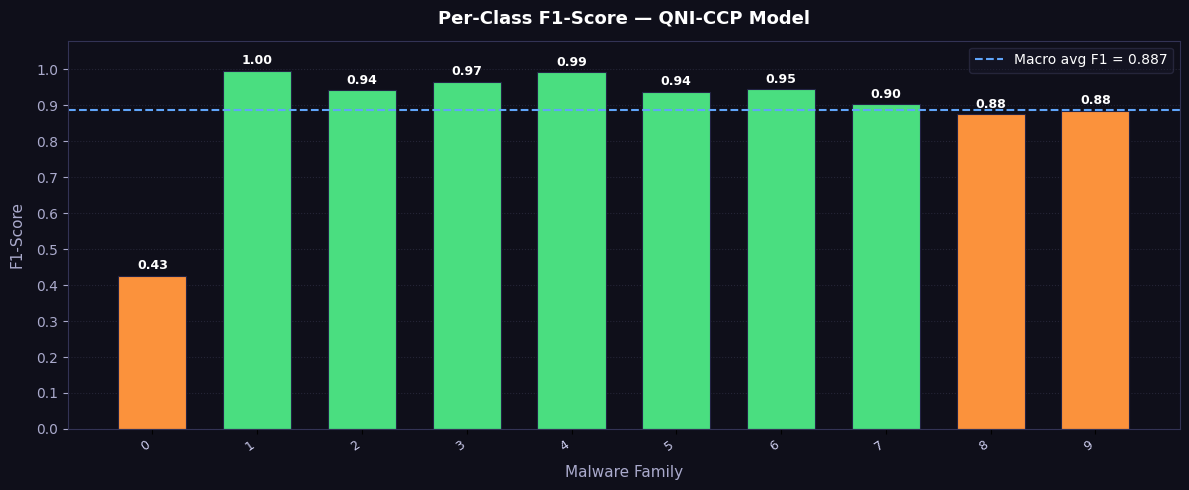

  Per-class F1 bar chart saved → per_class_f1_qni_model.png

EVALUATION SUMMARY

  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : QNI1.pth  (epoch 15)
  Test samples    : 3458
  Classes         : 10

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : 0.9164 (91.64%)
  QNI-CCP robustness     : 0.8988 (89.88%)
  Robustness drop        : 1.76 pp

  ── Classification ────────────────────────────────
  Macro F1               : 0.8866
  Weighted F1            : 0.9134
  Macro Precision        : 0.8812
  Macro Recall           : 0.8963

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : 0.6420
  Feature Variance       : 0.0870
  Avg Confidence         : 0.8440
  High-conf patterns     : 46.4%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png



In [1]:
# in depth evaluation

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.manifold import TSNE                        # dimensionality reduction for t-SNE plot
from sklearn.metrics import (
    classification_report,                               # per-class precision/recall/f1
    confusion_matrix,                                    # class-wise prediction errors
    accuracy_score                                       # overall accuracy
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches                    # for custom legend entries
import seaborn as sns                                    # for confusion matrix heatmap
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION SCRIPT — HybridResNet v3 QNI-CCP Model
#
# WHAT THIS SCRIPT PRODUCES:
#   1. Classification Report  — per-class precision, recall, F1, support
#   2. t-SNE Plot (2D)        — visualise how the 64-dim GAP features cluster
#                               by malware family in 2D space
#   3. Confusion Matrix       — heatmap showing where the model confuses classes
#   4. Summary metrics table  — clean accuracy + QNI-CCP robustness accuracy
#
# HOW t-SNE WORKS HERE:
#   We extract the 64-dim GAP feature vector (z) for every test image.
#   t-SNE reduces these 64 dims → 2 dims while preserving neighbourhood
#   structure: samples with similar features end up close together in 2D.
#   Well-separated, compact clusters → the model has learned discriminative
#   features per malware family. This is Figure 4 from the paper.
#
# HOW TO READ THE CLASSIFICATION REPORT:
#   precision = TP / (TP + FP)  — when model predicts class X, how often correct?
#   recall    = TP / (TP + FN)  — of all actual class X samples, how many found?
#   f1-score  = harmonic mean of precision and recall
#   support   = number of test samples for that class
#   macro avg = unweighted mean across classes (treats all classes equally)
#   weighted  = mean weighted by support (accounts for class imbalance)
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# CONFIG — must match training exactly
# ─────────────────────────────────────────────
n_qubits    = 8
q_depth     = 6
q_out_dim   = 3 * n_qubits    # 24
num_classes = 10
batch_size  = 32              # can increase for faster eval (no gradient needed)

CHECKPOINT_PATH = "QNI1.pth"   # your saved QNI-CCP model
EPSILON_Q       = 1.0                                 # same as training


# ─────────────────────────────────────────────
# TRANSFORMS — identical to training eval_transform
# ─────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Grayscale(1),             # single-channel grayscale
    transforms.Resize((32, 32)),         # resize to model input size
    transforms.ToTensor(),               # convert to float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)) # normalise to [-1, 1]
])


# ─────────────────────────────────────────────
# DATASETS — test set only for evaluation
# Also loading train set for centroid computation
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Test samples : {len(test_dataset)}")
    print(f"Train samples: {len(train_dataset)} (used only for centroid computation)")

    # class_names: list of folder names = malware family names
    # e.g. ['Adware', 'Backdoor', 'Ransomware', ...]
    class_names = test_dataset.classes
    print(f"Classes ({num_classes}): {class_names}")
except Exception as e:
    print(f"Dataset load error: {e}")
    raise

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITION — byte-for-byte identical to training script
# Must match exactly or load_state_dict() will fail with key mismatches
# ══════════════════════════════════════════════════════════════════════════════

dev_qml = qml.device("default.qubit", wires=n_qubits)   # PennyLane device

@qml.qnode(dev_qml, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: 16 bridge values → RY/RZ rotations on 8 qubits
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)   # first 8 → RY
        qml.RZ(inputs[..., i + n_qubits], wires=i)   # next  8 → RZ
    # Alternating brick entanglement + re-uploading per layer
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)
    # 3-axis Pauli measurements → 24 expectation values ∈ [-1,1]
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


class SEBlock(nn.Module):
    """Channel attention: (B,C,H,W) → GAP → FC → Sigmoid → channel rescale"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        return x * self.fc(s).view(b, c, 1, 1)


class ResBlock(nn.Module):
    """Residual block with SE attention + stochastic depth"""
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.se(self.conv_block(x))
        if self.training and self.drop_path_rate > 0:
            keep = 1 - self.drop_path_rate
            mask = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep).float()
            out  = out * mask / keep
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """Compress 64-dim backbone features → 16 quantum angles: (B,64)→(B,16)"""
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32), nn.LayerNorm(32),
            nn.GELU(), nn.Dropout(0.35), nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        return self.angle_scale * torch.sigmoid(self.project(x)) + self.angle_bias


class HybridResNet(nn.Module):
    """
    HybridResNet v3: (B,1,32,32) → backbone → GAP(B,64) → bridge → q_layer → classifier(B,10)
    GAP output (B,64) is the feature space visualised by t-SNE.
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(ResBlock(16,16,drop_path=0.10), ResBlock(16,16,drop_path=0.10))
        self.stage2 = nn.Sequential(ResBlock(16,32,stride=2,drop_path=0.15), ResBlock(32,32,drop_path=0.15))
        self.stage3 = nn.Sequential(ResBlock(32,64,stride=2,drop_path=0.20), ResBlock(64,64,drop_path=0.20))
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← t-SNE features extracted here
        self.bridge     = QuantumBridge(64, n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim*2), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(q_out_dim*2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        x = self.stage2(x); x = self.stage3(x)
        x = self.gap(x)                   # (B,64,1,1)
        x = x.view(x.size(0), -1)         # (B,64) ← latent space
        x = self.bridge(x)                # (B,16)
        x = self.q_layer(x)               # (B,24)
        return self.classifier(x)         # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Attaches to model.gap and captures (B,64,1,1) output automatically
    on every forward call. Call remove() when done to free memory.
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(self._capture)
    def _capture(self, module, inp, output):
        self.features = output
    def remove(self):
        self._handle.remove()


def extract_features_and_predictions(model, dataloader, device):
    """
    Single pass over the dataloader.
    Returns:
      all_features  : (N, 64) numpy array — GAP latent vectors for t-SNE
      all_labels    : (N,)    numpy array — true class indices
      all_preds     : (N,)    numpy array — predicted class indices
      all_probs     : (N, C)  numpy array — softmax probabilities (for confidence)

    Why one pass collects everything:
      The FeatureHook fires during model(x), giving us z (B,64).
      Simultaneously, model(x) returns logits → argmax → predictions.
      This avoids running the forward pass twice.
    """
    model.eval()
    all_features, all_labels, all_preds, all_probs = [], [], [], []

    hook = FeatureHook(model.gap)    # register hook on GAP layer once

    with torch.no_grad():            # no gradient needed for evaluation
        for x, y in tqdm(dataloader, desc="Extracting features", leave=False):
            x, y    = x.to(device), y.to(device)
            logits  = model(x)       # (B,10) — hook also fires, capturing (B,64,1,1)

            # gather GAP features from hook
            z = hook.features.view(hook.features.size(0), -1)   # (B,64,1,1) → (B,64)
            all_features.append(z.cpu().numpy())

            probs = F.softmax(logits, dim=1)                     # (B,10) probabilities
            preds = logits.argmax(dim=1)                         # (B,) predicted class

            all_labels.append(y.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    hook.remove()    # deregister hook to prevent memory leak

    return (
        np.concatenate(all_features, axis=0),   # (N, 64)
        np.concatenate(all_labels,   axis=0),   # (N,)
        np.concatenate(all_preds,    axis=0),   # (N,)
        np.concatenate(all_probs,    axis=0)    # (N, C)
    )


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean GAP feature (centroid) per class over the training set.
    Used for QNI robustness evaluation.
    Returns: (num_classes, 64) tensor
    """
    model.eval()
    hook         = FeatureHook(model.gap)
    sum_features = torch.zeros(num_classes, 64, device=device)
    count        = torch.zeros(num_classes,     device=device)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y = x.to(device), y.to(device)
            _    = model(x)          # fires hook
            z    = hook.features.view(hook.features.size(0), -1)   # (B,64)
            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_features[c] += z[mask].sum(dim=0)
                    count[c]        += mask.sum()

    hook.remove()
    return sum_features / count.clamp(min=1.0).unsqueeze(1)   # (num_classes, 64)


def evaluate_qni_robustness(model, dataloader, device, centroids, epsilon_q=1.0):
    """
    Measures accuracy when GAP features are perturbed by QNI-CCP attack.
    This is the adversarial robustness metric — how much does accuracy drop?

    Data flow:
      x → full forward (get z) → compute sensitivity → perturb z toward
      wrong centroid → bridge→q_layer→classifier → accuracy
    Returns: robustness accuracy (float)
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        # Extract z with gradient for sensitivity computation
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)   # enable grad on z only
        logits = model.classifier(model.q_layer(model.bridge(z)))
        F.cross_entropy(logits, y).backward()     # fills z.grad with sensitivity

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)   # L2-normalise

        z_det = z.detach()
        wrong = [np.random.choice([c for c in range(centroids.size(0)) if c != yi.item()])
                 for yi in y]
        mu_wrong    = centroids[torch.tensor(wrong, device=device)]   # (B,64)
        z_perturbed = z_det + epsilon_q * (S_norm * (mu_wrong - z_det))

        with torch.no_grad():
            logits_p = model.classifier(model.q_layer(model.bridge(z_perturbed)))
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def plot_tsne(features, labels, class_names, title="t-SNE of GAP Features",
              save_path="tsne_qni_model.png"):
    """
    Runs t-SNE on (N, 64) GAP features and plots 2D scatter.

    t-SNE parameters:
      n_components=2    : reduce to 2D for plotting
      perplexity=40     : roughly the number of close neighbours each point
                          considers. 30-50 works well for hundreds of samples.
                          Too low → tight blobs; too high → spread-out clouds.
      n_iter=1000       : number of optimisation steps (more = better quality)
      random_state=42   : reproducible layout
      learning_rate=200 : step size for t-SNE gradient descent

    Each dot = one test image. Colour = true malware family.
    Well-separated clusters → model learned discriminative features.
    Overlapping clusters → model confuses those families.
    """
    print("\nRunning t-SNE dimensionality reduction...")
    print(f"  Input shape  : {features.shape}  (N samples × 64 features)")

    tsne = TSNE(
        n_components=2,    # reduce to 2D for visualisation
        perplexity=40,     # neighbourhood size — 30-50 is standard
        n_iter=1000,       # optimisation iterations
        random_state=42,   # reproducible
        learning_rate=200, # gradient step size
        init='pca'         # PCA initialisation → more stable than random
    )
    embedded = tsne.fit_transform(features)   # (N, 64) → (N, 2)
    print(f"  Output shape : {embedded.shape}  (N samples × 2 t-SNE dimensions)")

    # ── Colour palette: one distinct colour per class ──────────────────────
    # Using tab10 for up to 10 classes (matches Matplotlib's default cycle)
    palette = plt.cm.get_cmap('tab10', num_classes)
    colors  = [palette(i) for i in range(num_classes)]   # list of RGBA tuples

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor('#0f0f1a')   # dark background — matches paper style
    ax.set_facecolor('#0f0f1a')

    for cls_idx in range(num_classes):
        mask = (labels == cls_idx)                      # boolean mask for this class
        ax.scatter(
            embedded[mask, 0],                          # t-SNE dim 1 (x-axis)
            embedded[mask, 1],                          # t-SNE dim 2 (y-axis)
            c=[colors[cls_idx]],                        # class colour
            label=class_names[cls_idx],                 # for legend
            s=18,                                       # marker size
            alpha=0.82,                                 # slight transparency
            edgecolors='none'                           # no border on dots
        )

    # ── Styling ────────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=15, fontweight='bold',
                 color='white', pad=16)
    ax.set_xlabel("t-SNE Dimension 1", fontsize=11, color='#aaaacc')
    ax.set_ylabel("t-SNE Dimension 2", fontsize=11, color='#aaaacc')
    ax.tick_params(colors='#666688')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    legend = ax.legend(
        title="Malware Family", title_fontsize=10,
        fontsize=9, loc='upper right',
        framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444466',
        labelcolor='white'
    )
    legend.get_title().set_color('white')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  t-SNE plot saved → {save_path}")
    return embedded   # return for potential further analysis


def plot_confusion_matrix(y_true, y_pred, class_names,
                          title="Confusion Matrix",
                          save_path="confusion_matrix_qni_model.png"):
    """
    Plots a normalised confusion matrix as a heatmap.

    normalise=True → each row sums to 1.0 (shows proportion, not raw count)
    This lets you see which classes are confused even if class sizes differ.

    Row   = true label  (what the sample actually is)
    Column = predicted label (what the model said it was)
    Diagonal = correct predictions (want these high)
    Off-diagonal = errors (want these near 0)

    Colour: dark blue = low fraction, bright yellow = high fraction.
    """
    cm = confusion_matrix(y_true, y_pred)                        # raw counts (C, C)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise each row to [0,1]

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    sns.heatmap(
        cm_norm,
        annot=True,                   # write numbers inside each cell
        fmt='.2f',                    # 2 decimal places
        cmap='YlOrRd',                # yellow→red colour scale (paper-like)
        xticklabels=class_names,      # column labels = predicted class
        yticklabels=class_names,      # row labels    = true class
        ax=ax,
        linewidths=0.5,
        linecolor='#1a1a2e',
        cbar_kws={'shrink': 0.8}
    )

    ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=14)
    ax.set_xlabel("Predicted Label", fontsize=11, color='#aaaacc', labelpad=10)
    ax.set_ylabel("True Label",      fontsize=11, color='#aaaacc', labelpad=10)
    ax.tick_params(axis='x', colors='#ccccee', labelsize=9, rotation=45)
    ax.tick_params(axis='y', colors='#ccccee', labelsize=9, rotation=0)

    # Style the colour bar
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color='#aaaacc')
    cbar.ax.tick_params(labelsize=9, colors='#aaaacc')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Confusion matrix saved → {save_path}")


def plot_per_class_f1(report_dict, class_names,
                      save_path="per_class_f1_qni_model.png"):
    """
    Bar chart of per-class F1-score.
    Makes it easy to spot which malware families are hardest to classify.
    Dashed line = macro average F1 across all classes.
    """
    f1_scores = [report_dict[cls]['f1-score'] for cls in class_names]   # one F1 per class
    macro_f1  = report_dict['macro avg']['f1-score']                     # average F1

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    # Colour bars: green if above macro avg, orange if below
    bar_colors = ['#4ade80' if f >= macro_f1 else '#fb923c' for f in f1_scores]
    bars = ax.bar(range(num_classes), f1_scores, color=bar_colors,
                  edgecolor='#222244', linewidth=0.8, width=0.65)

    # Value labels on top of bars
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

    # Macro avg reference line
    ax.axhline(y=macro_f1, color='#60a5fa', linestyle='--', linewidth=1.5,
               label=f'Macro avg F1 = {macro_f1:.3f}')

    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=35, ha='right',
                       fontsize=9, color='#ccccee')
    ax.set_yticks(np.arange(0, 1.05, 0.1))
    ax.tick_params(axis='y', colors='#aaaacc')
    ax.set_ylim(0, 1.08)
    ax.set_xlabel("Malware Family", fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_ylabel("F1-Score",       fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_title("Per-Class F1-Score — QNI-CCP Model",
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.legend(fontsize=10, labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#444466', framealpha=0.4)

    # Grid for readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.3, color='#555577')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Per-class F1 bar chart saved → {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Build model and load checkpoint ───────────────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])   # restore all trained weights

saved_epoch   = checkpoint.get('epoch', '?')
saved_val_acc = checkpoint.get('val_acc', '?')
print(f"  Checkpoint from epoch : {saved_epoch}")
print(f"  Saved val accuracy    : {saved_val_acc:.4f}" if isinstance(saved_val_acc, float)
      else f"  Saved val accuracy    : {saved_val_acc}")
print(f"  Training type         : {checkpoint.get('config', {}).get('training', 'QNI-CCP_only')}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters      : {total_params:,}")

# ── Step 2: Extract features + predictions in one forward pass ────────────────
print("\n" + "="*65)
print("STEP 1/4 — FEATURE EXTRACTION")
print("="*65)

features, true_labels, pred_labels, pred_probs = \
    extract_features_and_predictions(model, test_loader, device)

# features     : (N, 64) — what t-SNE will visualise
# true_labels  : (N,)    — ground truth class indices
# pred_labels  : (N,)    — model predictions
# pred_probs   : (N, C)  — confidence per class

print(f"\n  Samples extracted : {len(true_labels)}")
print(f"  Feature dimension : {features.shape[1]}  (GAP output before bridge)")


# ── Step 3: Classification Report ─────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 2/4 — CLASSIFICATION REPORT")
print("="*65)

overall_acc = accuracy_score(true_labels, pred_labels)   # fraction correctly classified
print(f"\n  Clean Test Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)\n")

# classification_report: per-class P / R / F1 + macro/weighted averages
# output_dict=True → returns dict so we can also use values programmatically
report_str  = classification_report(
    true_labels, pred_labels,
    target_names = class_names,   # use folder names as class labels
    digits       = 4              # 4 decimal places
)
report_dict = classification_report(
    true_labels, pred_labels,
    target_names = class_names,
    digits       = 4,
    output_dict  = True           # also return as dict for programmatic use
)
print(report_str)

# ── Step 4: Compute QNI robustness ────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION")
print("="*65)

print("\nComputing training-set centroids for QNI perturbation...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
# centroids: (10, 64) — mean GAP feature vector per malware family

print("\nApplying QNI-CCP attack on test set...")
qni_acc = evaluate_qni_robustness(model, test_loader, device, centroids, EPSILON_Q)

print(f"\n  Clean Test Accuracy         : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"  Under QNI-CCP Perturbation  : {qni_acc:.4f}  ({qni_acc*100:.2f}%)")
print(f"  Robustness drop             : {(overall_acc - qni_acc)*100:.2f} pp")
# pp = percentage points — absolute difference in accuracy

# ── Step 5: Additional latent-space metrics (Table 6 from paper) ──────────────
print("\n" + "="*65)
print("STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)")
print("="*65)

# Entropy: measures how evenly the model distributes probability across classes
# High entropy → uncertain/flat predictions; Low entropy → confident predictions
# Computed per sample as: H = -Σ p_i * log(p_i), then averaged
eps         = 1e-9                                           # avoid log(0)
entropy     = -np.sum(pred_probs * np.log(pred_probs + eps), axis=1)   # (N,) per sample
mean_entropy = entropy.mean()                                # scalar — avg uncertainty

# Feature Variance: spread of activation values across the 64-dim feature space
# Low variance → compact, uniform features (paper: QNNs have lower variance)
feature_variance = features.var(axis=0).mean()   # mean variance across 64 dims

# Unique Patterns: distinct activation patterns (rounded to 1 decimal)
# Proxy for how many distinct "modes" the feature extractor produces
unique_patterns = len(np.unique(np.round(features, 1), axis=0))

# Average Confidence: mean probability assigned to the predicted class
# High confidence → model is certain; should correlate with accuracy
max_probs        = pred_probs.max(axis=1)           # (N,) — confidence per sample
avg_confidence   = max_probs.mean()                  # scalar
conf_std         = max_probs.std()                   # scalar — consistency of confidence

# High-confidence patterns: fraction of samples where confidence > 0.90
high_conf_frac = (max_probs >= 0.90).mean() * 100   # as percentage

print(f"\n  {'Metric':<35} {'Value':>10}")
print(f"  {'-'*45}")
print(f"  {'Entropy (avg prediction entropy)':<35} {mean_entropy:>10.4f}")
print(f"  {'Feature Variance (avg across dims)':<35} {feature_variance:>10.4f}")
print(f"  {'Unique Patterns':<35} {unique_patterns:>10d}")
print(f"  {'High-confidence patterns (≥90%)':<35} {high_conf_frac:>9.1f}%")
print(f"  {'Average confidence':<35} {avg_confidence:>10.4f}")
print(f"  {'Confidence std dev':<35} {conf_std:>10.4f}")


# ── Step 6: Generate all plots ────────────────────────────────────────────────
print("\n" + "="*65)
print("GENERATING PLOTS")
print("="*65)

# t-SNE: visualise 64-dim features in 2D
# Each dot = one test sample, colour = true malware family
# Compact separated clusters → good feature learning
tsne_emb = plot_tsne(
    features, true_labels, class_names,
    title     = "t-SNE of GAP Features — HybridResNet v3 (QNI-CCP)",
    save_path = "tsne_qni_model.png"
)

# Confusion matrix: (C×C) heatmap of normalised predictions
# Bright diagonal → correct; off-diagonal bright cells → systematic confusions
plot_confusion_matrix(
    true_labels, pred_labels, class_names,
    title     = "Confusion Matrix — HybridResNet v3 (QNI-CCP)\n(row-normalised)",
    save_path = "confusion_matrix_qni_model.png"
)

# Per-class F1 bar chart: spot which families are hardest
plot_per_class_f1(
    report_dict, class_names,
    save_path = "per_class_f1_qni_model.png"
)


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("EVALUATION SUMMARY")
print("="*65)
print(f"""
  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : {CHECKPOINT_PATH}  (epoch {saved_epoch})
  Test samples    : {len(true_labels)}
  Classes         : {num_classes}

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : {overall_acc:.4f} ({overall_acc*100:.2f}%)
  QNI-CCP robustness     : {qni_acc:.4f} ({qni_acc*100:.2f}%)
  Robustness drop        : {(overall_acc-qni_acc)*100:.2f} pp

  ── Classification ────────────────────────────────
  Macro F1               : {report_dict['macro avg']['f1-score']:.4f}
  Weighted F1            : {report_dict['weighted avg']['f1-score']:.4f}
  Macro Precision        : {report_dict['macro avg']['precision']:.4f}
  Macro Recall           : {report_dict['macro avg']['recall']:.4f}

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : {mean_entropy:.4f}
  Feature Variance       : {feature_variance:.4f}
  Avg Confidence         : {avg_confidence:.4f}
  High-conf patterns     : {high_conf_frac:.1f}%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png
""")